# Lab 3 - Gradient descent and regularization </br> M1 Data Science, ML1

In [18]:
# %%
# "IPython magic command" to sutomatically reload the imported packages after changes in a package
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import sklearn

# plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Helvetica"]})
# plt.rc("text", usetex=True)

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc("font", size=SMALL_SIZE)  # default text size
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

# display backend for matplotlib
%matplotlib inline
# %matplotlib widget
# %matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div class="alert alert-danger" style="margin-top: 0px">

**To be completed**

Lab report written by: Clément Martin, Rami El Hage, 2025-2026.

</div>

# Exercise 1: introduction to gradient descent

Consider the minimization of a quadratic form in $\mathbb{R}^2$ ($N=2$)

$$ f(x) = \frac{1}{2}  \big( x_1^2 + \eta x_2^2 \big) $$ 

with $\eta>0$ fixed. The function and gradient of the function are implemented below.

In [19]:
eta = 8
f = lambda x: (x[..., 0] ** 2 + eta * x[..., 1] ** 2) / 2
grad_f = lambda x: np.array([x[0], eta * x[1]])

The contourplot of the function $f$ is displayed below, with its unique global minimizer $\mathbf{x}^*$ (kown in this case).

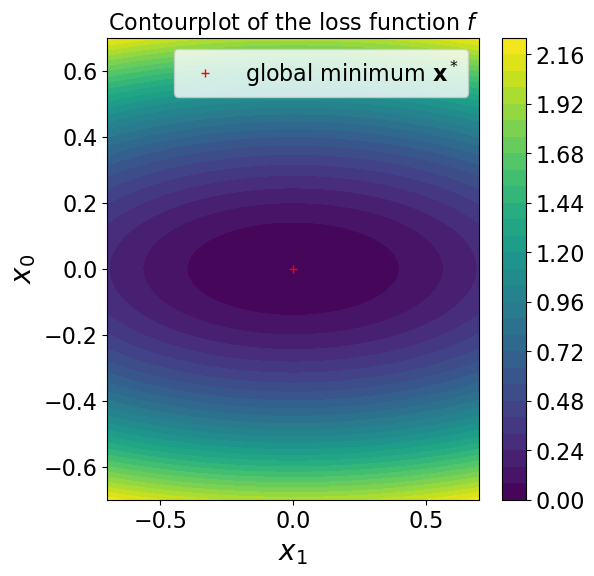

In [20]:
t = np.linspace(-0.7, 0.7, 101)
[u, v] = np.meshgrid(t, t)
F = (u**2 + eta * v**2) / 2

plt.figure(figsize=(6, 6))
plt.contourf(t, t, F, 35)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_0$")
plt.colorbar()
plt.plot(0, 0, "r+", label=r"global minimum $\mathbf{x}^*$")
plt.title(r"Contourplot of the loss function $f$")
plt.legend()
plt.show()

The rest of the exercise is aimed at illustrating the behaviour of the gradient descent algorithm to find the minimizer of the function $f$.

<div class="alert" style="margin-top: 0px">

1. Given the code provided for the objective function `f` and its gradient `grad_f`, complete the code cell below to implement a `gradient_descent` algorithm.

</div>

In [21]:
def gradient_descent(
    x0: np.ndarray, f, grad_f, tau: float, niter: int
) -> list[np.ndarray, np.ndarray]:
    r"""Basic implementation of the gradient descent algorithm, with fixed
    stepsize and predefined number of iterations.

    Parameters
    ----------
    x0 : _np.ndarray
        Algorithm starting point.
    f : lambda function
        Lambda function used to evaluate the loss function.
    grad_f : lambda function
        Lambda function used to evaluate the gradient of the loss function.
    tau : float
        Algorithm stepsize.
    niter : int
        Number of iterations of the algorithm.

    Returns
    -------
    X: np.ndarray
        Sequence of iterates generated by then algorithm, with shape `(niter, *x0.shape)`.
    objective: np.ndarray
        Value of the objective function evaluated in each iterate, of shape `(niter+1, )`.
    """
    X = np.zeros((niter + 1, *x0.shape))
    X[0] = x0
    objective = np.zeros((niter + 1,))

    # Evaluate initial loss at starting point
    objective[0] = f(X[0])

    for k in range(niter):
        # Gradient descent update formula
        X[k + 1] = X[k] - tau*grad_f(X[k])

        # Evaluate objective at new iterate
        objective[k+1] = f(X[k+1])

    return X, objective

<div class="alert" style="margin-top: 0px">

2. Use the code provided below to run the algorithm with different values of $\tau \in \{0.25,0.225,0.2,0.05\}$. Qualitatively, is the algorithm converging for each of these values? For which value does it converge the fastest to the solution?

</div>

In [22]:
niter = 30
stepsize = [0.25,0.225, 0.2, 0.05]
x0 = np.array([0.6, 0.6])

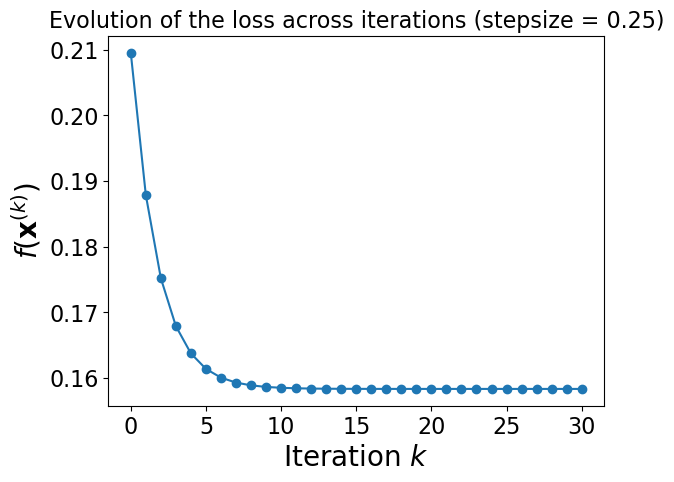

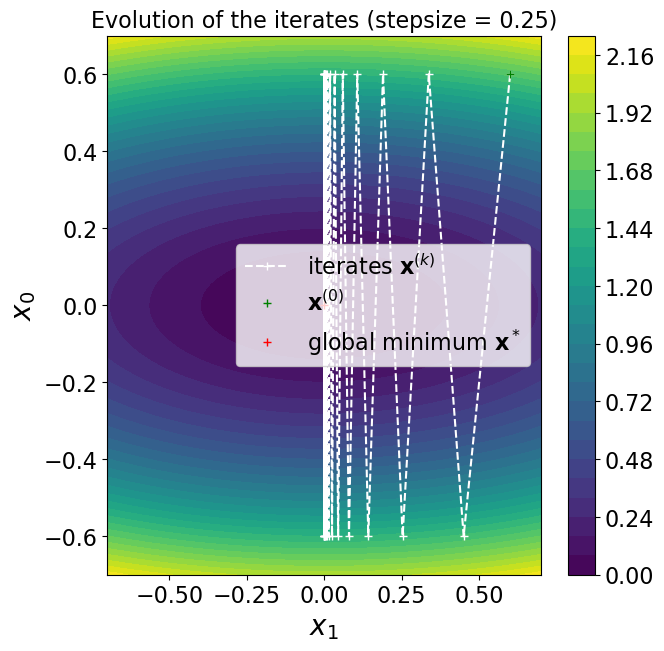

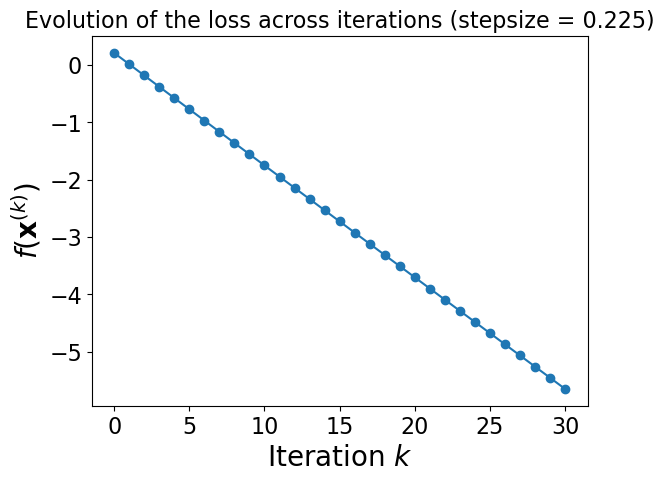

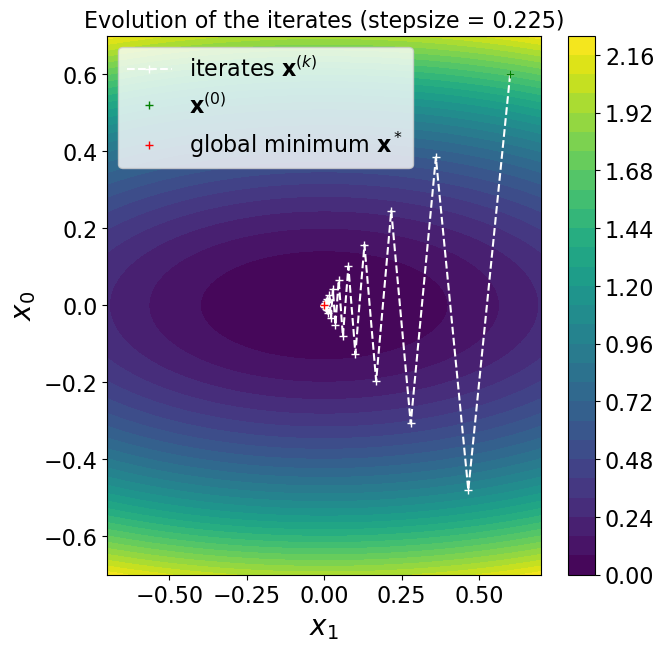

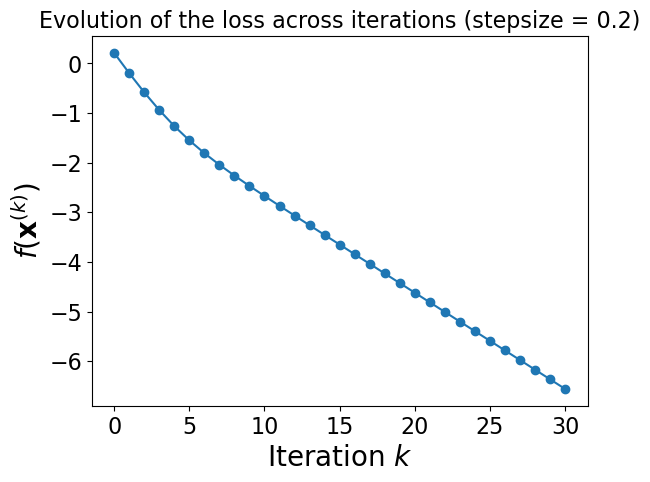

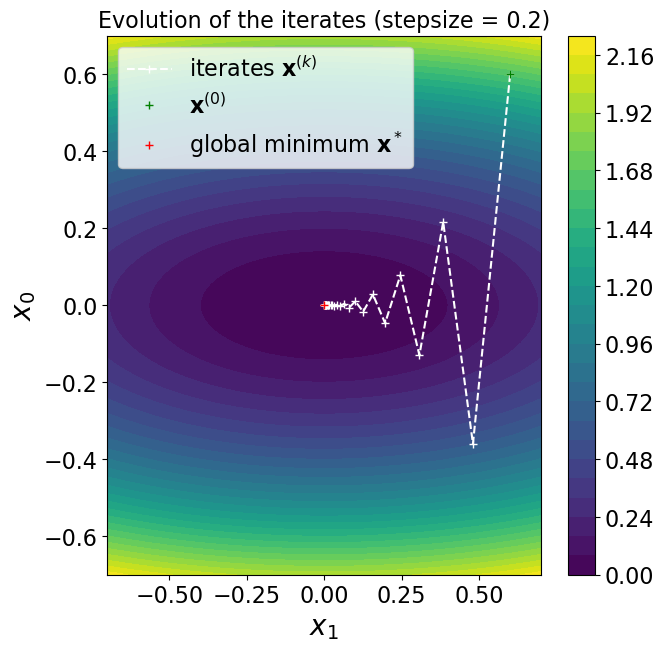

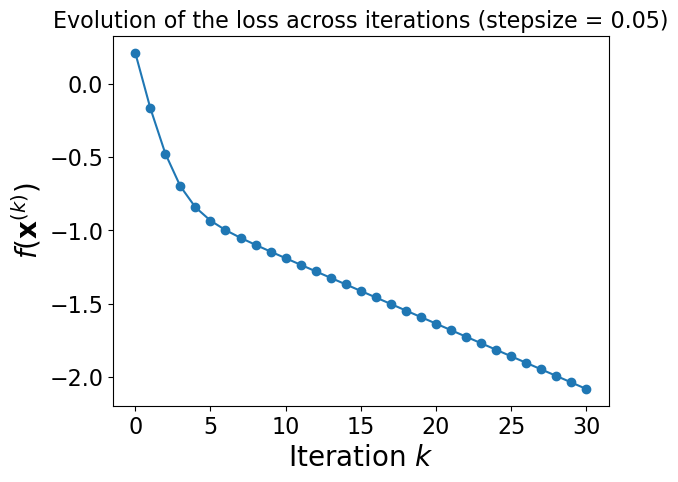

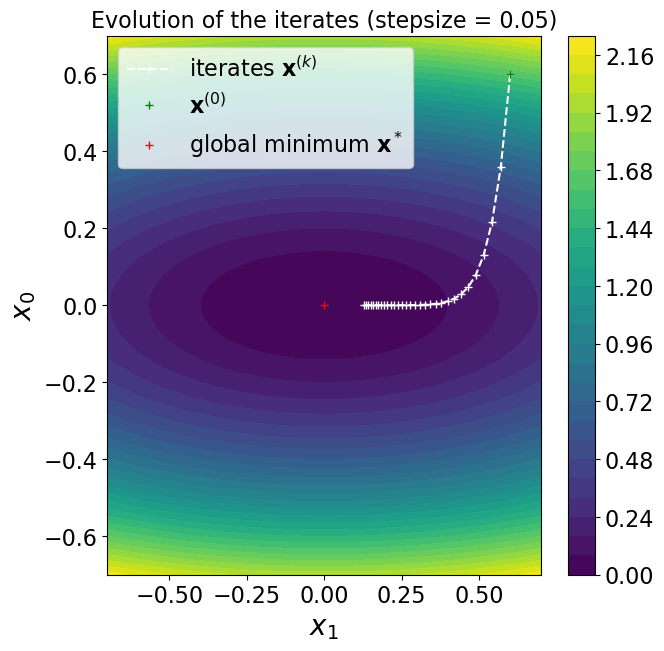

In [23]:
#We apply the gradient_descent and we plot its evolution for each stepsize

for s in stepsize:
    X, objective = gradient_descent(x0, f, grad_f, s, niter)

    plt.figure()
    plt.plot(np.log10(objective), "o-")
    plt.xlabel(r"Iteration $k$")
    plt.ylabel(r"$f(\mathbf{x}^{(k)})$")
    plt.title(f"Evolution of the loss across iterations (stepsize = {s})")
    plt.show()

    plt.figure(figsize=(7, 7))
    plt.contourf(t, t, F, 35)
    plt.plot(X[:, 0], X[:, 1], "w--+", label=r"iterates $\mathbf{x}^{(k)}$")
    plt.plot(x0[0], x0[1], "g+", label=r"$\mathbf{x}^{(0)}$")
    plt.plot(0, 0, "r+", label=r"global minimum $\mathbf{x}^*$")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_0$")
    plt.colorbar()
    plt.legend()
    plt.title(f"Evolution of the iterates (stepsize = {s})")
    plt.show()

<div class="alert alert-warning" style="margin-top: 0px">
Answer question 2:

From all graphs, we can observe that it converges for each value of $\tau$. However, more its value is low, faster it converges to x*
</div>

<div class="alert" style="margin-top: 0px">

3. Try a different initial estimate (i.e., a randomly generated one), with $\tau = 0.2$. Does the algorithm still converge to the solution of the problem for this example? 

> Indication: Do not hesitate to increase the number of iterations to answer the question.

</div>

In [24]:
niter = 50
stepsize = 0.2

# We create a random vector as an initial estimate

x0 = np.random.rand(2)

X, objective = gradient_descent(x0, f, grad_f, stepsize, niter)

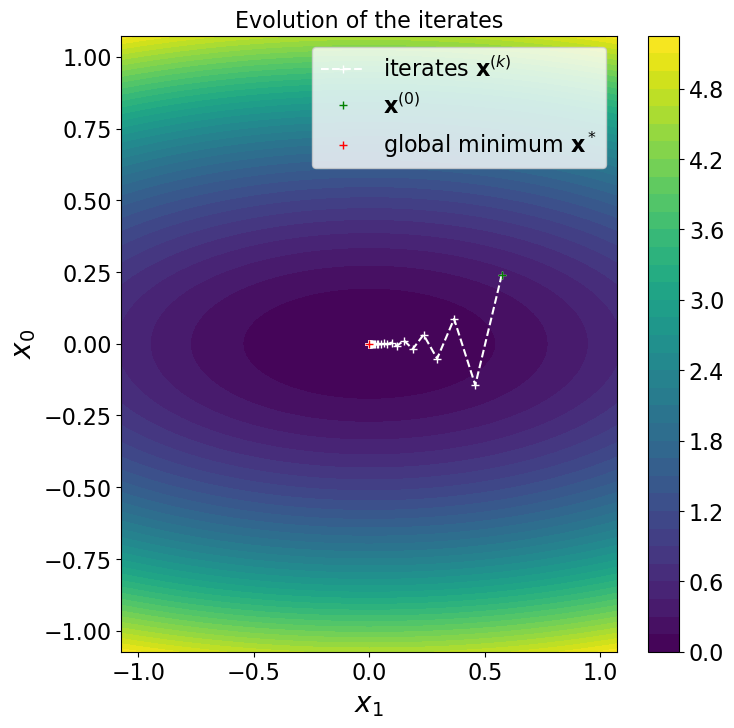

In [25]:
r = np.maximum(np.abs(np.min(x0)), np.abs(np.max(x0)))

t = np.linspace(-r - 0.5, r + 0.5, 101)
[u, v] = np.meshgrid(t, t)
F = (u**2 + eta * v**2) / 2

plt.figure(figsize=(8, 8))
plt.contourf(t, t, F, 35)
plt.plot(X[:, 0], X[:, 1], "w--+", label=r"iterates $\mathbf{x}^{(k)}$")
plt.plot(x0[0], x0[1], "g+", label=r"$\mathbf{x}^{(0)}$")
plt.plot(0, 0, "r+", label=r"global minimum $\mathbf{x}^*$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_0$")
plt.colorbar()
plt.legend()
plt.title(r"Evolution of the iterates")
plt.show()

<div class="alert alert-warning" style="margin-top: 0px">
Answer question 3:

We tried many times to check the convergence and it converges each time, so even if we have a random initial estimate, the gradient descent still converges.  

</div>

# Exercise 2: ridge regression

Let $N, M$ be two postive integers, and consider a dataset $\mathcal{D} = \{ (y_n \mathbf{x}_n) \}_{1 \leq n \leq N}$, with targets $\mathbf{y} = (y_n)_{1 \leq n \leq N} \in \mathbb{R}^N$, and (standardized) data $\mathbf{X} = [\mathbf{x}_1, \dotsc, \mathbf{x}_N]^T \in \mathbb{R}^{N \times M}$.

This exercise is aimed at performing ridge regression with `sklearn`, formulated as follows

\begin{equation}
    \tag{ridge}
    \boldsymbol{\beta}^* \in \arg\min_{\boldsymbol{\beta} = (\beta_m)_{0 \leq m \leq M}} \frac{1}{2N} \| \mathbf{y} - \widetilde{\mathbf{X}} \boldsymbol{\beta} \|_2^2 + \lambda \|\boldsymbol{\beta}_{1:M} \|_2^2,
\end{equation}

with $\widetilde{\mathbf{X}} = [\phi(\mathbf{x}_1), \dotsc, \phi(\mathbf{x}_n)]^T \in \mathbb{R}^{N \times (M + 1)}$ and $\phi: \mathbf{x} \mapsto [1, \mathbf{x}^T]^T$.

We will use the `California house` dataset, loaded below.

In [9]:
# loading the dataset
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

# X = housing.data, y = housing.target
X = housing.data
y = housing.target

print(X.shape, y.shape)
print(housing.feature_names)

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


<div class="alert" style="margin-top: 0px">

1. Divide the data into a train and a test set, the latter composed of 20% of the samples.

    In the following, any cross-validation step will be conducted on the training set, the test step being kept the assess the model quality.

> Indication: use the function [`sklearn.model_selection.train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#train-test-split).

</div>

In [10]:
# TODO: complete code cell
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X,y, test_size=0.2)

<div class="alert" style="margin-top: 0px">

2. Adapt the code below to perform ridge regression, adjusting the regularization parameter $\lambda$ in the set $\{10^{-3}, 10^{-2}, 10^{-1}, 1, 10, 100, 1000\}$ with 5-fold cross-validation.

> Indication: 
> - to perform ridge regression with cross-validation for the choice of the regularization parameter, see [sklearn.linear_model.RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html) with the [associated example](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification) from the documentation;
> - take a look at the following fields from the object `pipe.named_steps['ridgecv']`, in particular `alpha_`, `coef_`, `intercept_`, and `best_score_`.
<!-- > - see the `sklearn` tutorial on [grid-search](https://scikit-learn.org/stable/modules/grid_search.html) to adjust the regularization parameter. -->

</div>

In [11]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# TODO: complete instructions to create the ridge_regression and scaler variables

regularization_parameter = [0.001, 0.01, 0.1, 1, 10, 100, 1000]


# Define a Ridge regression model with cross-validation 
ridge_regression = RidgeCV(alphas=regularization_parameter, cv=5)

# Create a standard scaler
ridge_scaler = StandardScaler()

# Build a pipeline that first standardizes the data, then applies RidgeCV.
ridge_pipe = Pipeline(steps=[("scaler", ridge_scaler), ("ridgecv", ridge_regression)])
ridge_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('ridgecv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alphas,"[0.001, 0.01, ...]"
,fit_intercept,True
,scoring,None
,cv,5


<div class="alert" style="margin-top: 0px">

3. Complete the code below to visualize the regression coefficients in function of the value of the regularization parameter $\lambda$. Comment on the evolution of their magnitude.

</div>

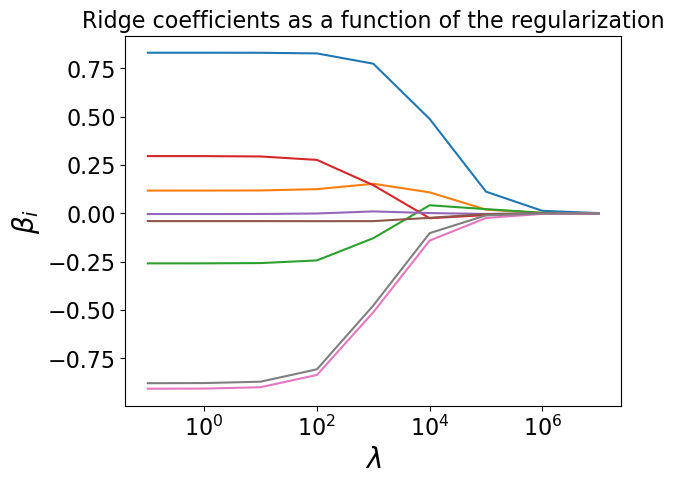

In [12]:
# code
# https://scikit-learn.org/stable/auto_examples/linear_model/plot_ridge_path.html

alphas = [1e-1, 1, 10, 100, 1000,10000, 1e5, 1e6,1e7]
coefs = []
pipe_loop = sklearn.pipeline.make_pipeline(
    sklearn.preprocessing.StandardScaler(),
    sklearn.linear_model.Ridge(fit_intercept=True),
)

for a in alphas:
    pipe_loop.set_params(**{"ridge__alpha": a})

    # TODO: complete instructions below
    # fit pipeline on X_train, y_train
    pipe_loop.fit(X_train, y_train)

    # append regressor to the coefs list
    coefs.append(pipe_loop.named_steps['ridge'].coef_)

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\beta_i$")
plt.title("Ridge coefficients as a function of the regularization")
plt.axis("tight")
plt.show()

<div class="alert alert-warning" style="margin-top: 0px">

Answer question 3:

As the regularization parameter $\lambda$ increases, all coefficient converges to 0. It was expected since the ridge regression improves stability with a big regularization. If $\lambda$ is small, the model is similar to least squares.
</div>

<div class="alert" style="margin-top: 0px">

4. Retrieve the best regressor obtained on the training set $\widehat{\boldsymbol{\beta}}$, and evaluate the MSE on the scaled test set.

</div>

The best alpha is 1000
The corresponding MSE is 0.5560905521160256
The best regressor coefficients are:
[ 0.77349766  0.1528792  -0.12839132  0.1456949   0.01002699 -0.04024936
 -0.51115478 -0.47657884]


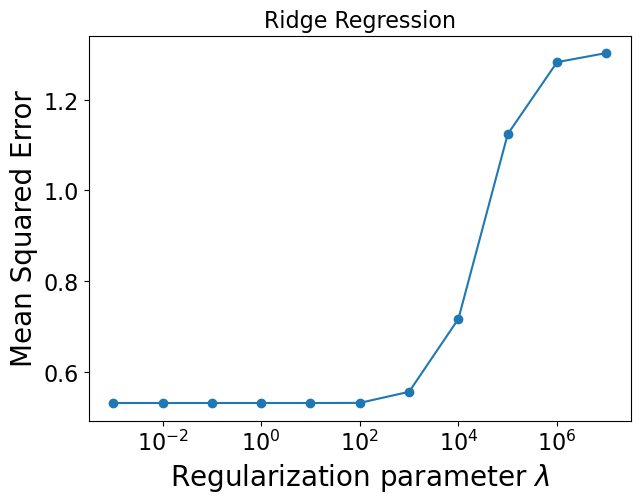

In [13]:
alphas = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000,10000, 1e5, 1e6,1e7]
pipe_loop = sklearn.pipeline.make_pipeline(
    sklearn.preprocessing.StandardScaler(),
    sklearn.linear_model.Ridge(fit_intercept=True),
)
# Lists to store results
all_mse = []
coefs = []

for a in alphas:
    pipe_loop.set_params(**{"ridge__alpha": a})

    # fit pipeline on X_train, y_train
    pipe_loop.fit(X_train, y_train)
    
    y_pred = pipe_loop.predict(X_test)

    # Compute Mean Squared Error between predictions and true values
    mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
    all_mse.append(mse)

    # append regressor to the coefs list
    coefs.append(pipe_loop.named_steps['ridge'].coef_)
    
best_regressor_index = np.argmin(coefs)
print(f"The best alpha is {alphas[best_regressor_index]}")
print(f"The corresponding MSE is {all_mse[best_regressor_index]}")
print(f"The best regressor coefficients are:\n{coefs[best_regressor_index]}")


# Plot evolution of MSE as function of alpha
plt.figure(figsize=(7,5))
ax = plt.gca()
ax.plot(alphas, all_mse, "-o")
ax.set_xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("Ridge Regression")
plt.axis("tight")
plt.show()


<div class="alert alert-warning" style="margin-top: 0px">

Answer question 4:

As we can see with the result, we obtained a mean squared error of 0.57 with the best regressor $\boldsymbol{\beta}^*$, indicating that the model does not suffer from overfitting.

</div>

## (Bonus) Lasso regression

Exercise 2 can be easily adapted to perform Lasso regression, which is formulated as

\begin{equation*}
    \tag{Lasso}
    \boldsymbol{\beta}^* \in \arg\min_{\boldsymbol{\beta} = (\beta_m)_{0 \leq m \leq M} } \frac{1}{2N} \| \mathbf{y} - \widetilde{\mathbf{X}} \boldsymbol{\beta} \|_2^2 + \lambda \| \boldsymbol{\beta}_{1:M} \|_1.
\end{equation*}

<div class="alert" style="margin-top: 0px">

5. (Bonus) Adapt the code from question 1 to perform Lasso regression, adjusting the regularization parameter in the set $\{10^{-3}, 10^{-2}, 10^{-1}, 1\}$ using 5-fold cross-validation.

    > Indication: 
    > to perform Lasso regression with cross-validation for the choice of the regularization parameter, see [sklearn.linear_model.LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html).

</div>

In [14]:
# code

<div class="alert" style="margin-top: 0px">

6. (Bonus) Visualize the regression coefficients in function of the value of the regularization parameter $\lambda$. Comment on the evolution of their magnitude, and compare with the results obtained in question 2.

</div>

In [15]:
# code

<div class="alert alert-warning" style="margin-top: 0px">

Answer question 6:

...

</div>

<div class="alert" style="margin-top: 0px">

7. (Bonus) Retrieve the best regressor obtained on the training set $\widehat{\boldsymbol{\beta}}$, and evaluate the error on the scaled test set.

</div>

In [16]:
# code

---

End of lab3.